Pilot Analysis 

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Get the script's directory and search upward for Data and Results folders
current = Path(os.getcwd())

# Walk up until we find a folder that contains both Data and Results
while current != current.parent:
    if (current / 'Data').exists() and (current / 'Results').exists():
        repo_root = current
        break
    current = current.parent
else:
    raise FileNotFoundError("Could not find repo root (folder containing both Data and Results)")

# Define file paths relative to repo root
gt_path = repo_root / 'data/raw/pilot_ground_truth_raw.csv'
llm_path = repo_root / 'results/raw/pilot_llm_output_raw.csv'

# Load data
gt = pd.read_csv(gt_path)
llm = pd.read_csv(llm_path)

gt['issue_key'] = (
    gt['BUG-ID'].astype(str)
    .str.replace(' Raw','', regex=False)
    .str.replace(' Improved','', regex=False)
)

df = gt.merge(llm, on='issue_key', how='inner')

print("Ground Truth:", len(gt))
print("LLM Output:", len(llm))
print("Merged:", len(df))

print("\nRepo root found at:", repo_root)

df.head()

Ground Truth: 26
LLM Output: 26
Merged: 26

Repo root found at: c:\Users\lamso\Documents\My portfolio website\SWT301_SE1925_G6


,BUG-ID,S2R Label,S2R Irrep Category,Reason,OB Category,OB Label,Reason.1,EB Category,EB Label,Reason.2,...,prompt_version,seed,system_fingerprint,input_tokens,cached_input_tokens,output_tokens,total_tokens,cost_usd,timestamp,raw_response
0,MC-300962 Raw,Executable,NaN,NaN,Present,Sufficient,NaN,Present,Accurate,normally written,...,Prompts_Raw_Final_V10_PilotCandidate,210,fp_844ddd95ff,2432,0,204,2636,0.000487,2026-07-11T10:06:45,"{\r\n ""issue_key"": ""MC-300962"",\r\n ""steps_t..."
1,MC-299218 Raw,Non-Executable,Missing Information,No information for jukebox to work,Present,Sufficient,NaN,Not Present,NaN,No expected result given,...,Prompts_Raw_Final_V10_PilotCandidate,210,fp_844ddd95ff,2365,0,234,2599,0.000495,2026-07-11T10:06:55,"{\r\n ""issue_key"": ""MC-299218"",\r\n ""steps_t..."
2,MC-301018 Raw,Non-Executable,Missing Information,Does not tell how to pause game.,Present,Insufficient,"It's ambiguous what is meant by ""only pausing ...",Not Present,NaN,NaN,...,Prompts_Raw_Final_V10_PilotCandidate,210,fp_844ddd95ff,2337,0,220,2557,0.000483,2026-07-11T10:06:59,"{\r\n ""issue_key"": ""MC-301018"",\r\n ""steps_t..."
3,MC-300634 Raw,Non-Executable,Missing Information,Missing how to locate and structure the trapdo...,Present,Insufficient,Can not understand from lag aur hang. Wrong En...,Not Present,NaN,NaN,...,Prompts_Raw_Final_V10_PilotCandidate,210,fp_844ddd95ff,2373,0,231,2604,0.000495,2026-07-11T10:07:03,"{\r\n ""issue_key"": ""MC-300634"",\r\n ""steps_t..."
4,MC-299909 Raw,Executable,NaN,NaN,Present,Sufficient,NaN,Not Present,NaN,NaN,...,Prompts_Raw_Final_V10_PilotCandidate,210,fp_844ddd95ff,2450,0,222,2672,0.000501,2026-07-11T10:07:07,"{\r\n ""issue_key"": ""MC-299909"",\r\n ""steps_t..."


In [2]:

LABEL_MAP = {
    'S2R Label':'s2r_label',
    'S2R Irrep Category':'s2r_failure_type',
    'OB Category':'observed_behavior_presence',
    'OB Label':'observed_behavior_quality',
    'EB Category':'expected_behavior_presence',
    'EB Label':'expected_behavior_quality'
}

results=[]

for gt_col,llm_col in LABEL_MAP.items():
    y_true=df[gt_col].fillna('MISSING').astype(str)
    y_pred=df[llm_col].fillna('MISSING').astype(str)

    results.append({
        'Dimension':gt_col,
        'Accuracy':accuracy_score(y_true,y_pred),
        'Precision(Macro)':precision_score(y_true,y_pred,average='macro',zero_division=0),
        'Recall(Macro)':recall_score(y_true,y_pred,average='macro',zero_division=0),
        'F1(Macro)':f1_score(y_true,y_pred,average='macro',zero_division=0)
    })

metrics_df=pd.DataFrame(results)
metrics_df


,Dimension,Accuracy,Precision(Macro),Recall(Macro),F1(Macro)
0,S2R Label,0.961538,0.954545,0.968750,0.960061
1,S2R Irrep Category,0.461538,0.160000,0.184615,0.171429
2,OB Category,1.000000,1.000000,1.000000,1.000000
3,OB Label,0.846154,0.916667,0.666667,0.704545
4,EB Category,0.846154,0.830303,0.856209,0.837500
5,EB Label,0.230769,0.136364,0.214286,0.166667


In [3]:

# Average metrics across all annotation dimensions
metrics_df[['Accuracy','Precision(Macro)','Recall(Macro)','F1(Macro)']].mean().to_frame('Mean Score')


,Mean Score
Accuracy,0.724359
Precision(Macro),0.666313
Recall(Macro),0.648421
F1(Macro),0.640034


In [4]:

# Quality scoring logic adapted from kappa_pilot.py

def score_row(s2r, irr, ob, obl, eb, ebl):
    s2r=str(s2r).strip().lower()
    irr=str(irr).strip().lower()
    ob=str(ob).strip().lower()
    obl=str(obl).strip().lower()
    eb=str(eb).strip().lower()
    ebl=str(ebl).strip().lower()

    if s2r == 'executable':
        if ob == 'present' and obl == 'sufficient' and eb == 'present' and ebl == 'accurate':
            return 5
        return 4

    if irr == 'wrong information':
        return 1

    if ob == 'present' and eb == 'present':
        return 3

    if ob == 'present' or eb == 'present':
        return 2

    return 1

df['gt_score'] = df.apply(
    lambda r: score_row(
        r['S2R Label'],
        r['S2R Irrep Category'],
        r['OB Category'],
        r['OB Label'],
        r['EB Category'],
        r['EB Label']
    ), axis=1
)

df['llm_score'] = df.apply(
    lambda r: score_row(
        r['s2r_label'],
        r['s2r_failure_type'],
        r['observed_behavior_presence'],
        r['observed_behavior_quality'],
        r['expected_behavior_presence'],
        r['expected_behavior_quality']
    ), axis=1
)

df[['issue_key','gt_score','llm_score']].head()


,issue_key,gt_score,llm_score
0,MC-300962,5,5
1,MC-299218,2,2
2,MC-301018,2,2
3,MC-300634,2,2
4,MC-299909,4,4


In [5]:

from sklearn.metrics import accuracy_score

score_accuracy = accuracy_score(df['gt_score'], df['llm_score'])
score_f1 = f1_score(df['gt_score'], df['llm_score'], average='macro')

print("Quality Score Accuracy =", round(score_accuracy,4))
print("Quality Score F1 =", round(score_f1,4))

pd.crosstab(df['gt_score'], df['llm_score'],
            rownames=['Ground Truth'],
            colnames=['LLM'])


Quality Score Accuracy = 0.6923
Quality Score F1 = 0.5173


LLM,2,3,4,5
Ground Truth,,,,
1,1,0,0,0
2,10,2,0,0
3,0,2,0,1
4,0,0,3,3
5,0,0,1,3


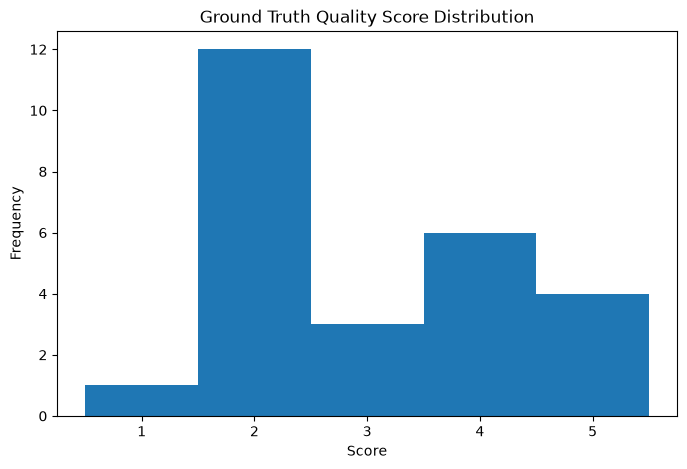

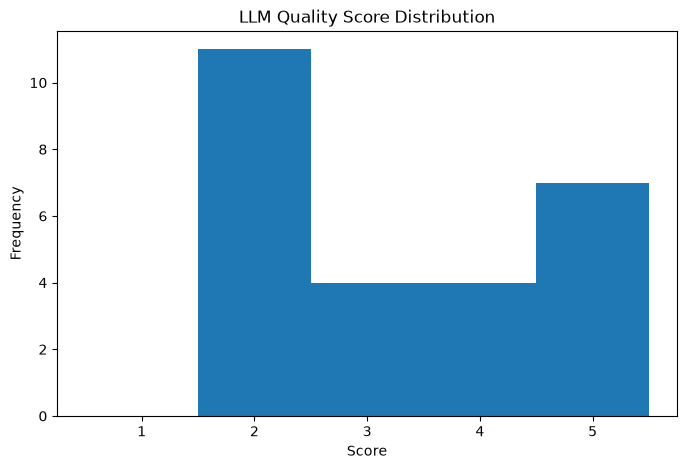

In [6]:

# Histogram distribution required by Section 7.3

plt.figure(figsize=(8,5))
plt.hist(df['gt_score'], bins=np.arange(1,7)-0.5)
plt.title('Ground Truth Quality Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['llm_score'], bins=np.arange(1,7)-0.5)
plt.title('LLM Quality Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()


In [7]:

# Descriptive statistics used to verify statistical assumptions

display(df['gt_score'].describe())
display(df['llm_score'].describe())

print('Interpretation:')
print('- If distribution approximately follows expected assumptions, keep test from proposal.')
print('- Otherwise document deviation in notes.md, project log, and amendment if required.')


count    26.000000
mean      3.000000
std       1.232883
min       1.000000
25%       2.000000
50%       2.500000
75%       4.000000
max       5.000000
Name: gt_score, dtype: float64

count    26.000000
mean      3.269231
std       1.282426
min       2.000000
25%       2.000000
50%       3.000000
75%       4.750000
max       5.000000
Name: llm_score, dtype: float64

Interpretation:
- If distribution approximately follows expected assumptions, keep test from proposal.
- Otherwise document deviation in notes.md, project log, and amendment if required.


In [8]:

# Cohen's Kappa (direct calculation)

from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(df['gt_score'], df['llm_score'])
print("Cohen Kappa =", round(kappa,4))


Cohen Kappa = 0.5667


In [9]:

# Run official script

import subprocess, os

script='Scripts/kappa_pilot.py'

if os.path.exists(script):
    subprocess.run(['python', script])
else:
    print('Copy kappa_pilot.py into Scripts/ and run this cell.')


Copy kappa_pilot.py into Scripts/ and run this cell.
